## **OlmoEarth**

Site oficial: https://docs.olmoearth.allenai.org/

O presente tutorial foi traduzido por Alisson de Oliveira (https://github.com/AOlivr) com base no tutorial original disponibilizado pela equipe do OlmoEarth (acesso em: https://docs.olmoearth.allenai.org/embeddings/). Para conhecer esse *Foundation Model*, acesse o *paper*: https://doi.org/10.48550/arXiv.2511.13655.

# Começando com OlmoEarth: *Embeddings* e *Fine-tuning*

**Um tutorial de classificação de uso e cobertura da terra (*land-use and land-cover*) no Quênia (área de estudo)**

Esse tutorial demonstra como usar o [OlmoEarth](https://huggingface.co/collections/allenai/olmoearth), um modelo fundacional (*foundation model*) que é estado da arte (*state-of-the-art*) em observação da Terra, fazendo uma classificação. Vamos trabalhar com dados da *African Wildfire Foundation* (AWF) das proximidades do Parque Nacional de Amboseli, na região sul do Quênia.

## O que você aprenderá?

1. **Extração de *embeddings*** a partir de imagens de satélites usando o OlmoEarth em prototipagem rápida;
2. **Treinar classificadores simples** (kNN, linear probe) utilizando os *embeddings*;
3. **Fine-tune OlmoEarth** com o objetivo de maximizar a acurácia (parte 2 do tutorial).

## Porque duas abordagens?

| Abordagem | Acurácia | Tempo | GPU (memória) | Adequado |
|----------|----------|------|------------|----------|
| *Embeddings* + kNN/LP | ~70-75% | Minutos | ~2-3 GB | Prototipagem rápida, recursos computacionais limitados |
| *Fine-tuning* (4 épocas) | ~70-75% | ~15-20 minutos | ~4-6 GB | Rápido *fine-tuning* |
| *Fine-tuning* (30 épocas) | ~82-87% | ~2-3 horas | ~4-6 GB | Melhorar a acurácia |

## Requisitos

- Google Colab com GPU (T4 é suficiente);
- Tempo estimado: de 30 a 45 minutos nas configurações padrão (o número de épocas pode ser adaptado pelo usuário).

**Vamos começar!**

---
## 1. Configuração e instalação

Primeiramente, vamos verificar se temos acesso a GPU e instalar os pacotes necessários.

In [ ]:
# Checa se há GPU disponível
!nvidia-smi

Fri Sep 18 19:09:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Instalação dos pacotes necessários (talvez leve mais de 3 minutos)
!pip install -q olmoearth_pretrain rslearn scikit-learn matplotlib einops huggingface_hub 'jsonargparse[signatures]>=4.27.7'

In [ ]:
# Importações (imports) básicas
import os
import json

# Ativar o fallback do MPS para operações não suportadas (necessário para o OlmoEarth no Apple Silicon)
# IMPORTANTE: deve ser configurado antes de importar o torch
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from collections import Counter

# Machine learning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import sklearn.preprocessing as preprocessing

# Sensoriamento remoto
import rasterio
from einops import rearrange
from scipy.ndimage import zoom

# rslearn
from rslearn.dataset import Dataset
from upath import UPath

# OlmoEarth
from olmoearth_pretrain.model_loader import ModelID, load_model_from_id
from olmoearth_pretrain.datatypes import MaskedOlmoEarthSample, MaskValue
from olmoearth_pretrain.data.normalize import load_computed_config

# Função auxiliar de detecção de dispositivos
def get_device():
    """Escolhe o melhor dispositivo (CUDA > MPS > CPU)."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

def print_device_info(device):
    """Imprime informações do dispositivo (prints)."""
    if device.type == "cuda":
        print(f"Dispositivo em uso: {device}")
        print(f"  GPU: {torch.cuda.get_device_name(0)}")
        print(f"  Memória: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    elif device.type == "mps":
        print(f"Dispositivo em uso: {device} (Apple Silicon GPU)")
        print("  Observação: algumas operações talvez ocorram na CPU")
    else:
        print(f"Dispositivo em uso: {device}")
        print("  Warning: Não há GPU disponível, o treinamento será mais demorado que o previsto")

device = get_device()
print_device_info(device)

/usr/local/lib/python3.13/dist-packages/olmoearth_pretrain/model_loader.py:38: UserWarning: olmo-core not installed. Running in inference-only mode. For training: pip install olmoearth-pretrain[training]
  from olmoearth_pretrain.config import Config


Dispositivo em uso: cuda
  GPU: Tesla T4
  Memória: 15.6 GB


---
## 2. *Download* do conjunto de dados (*dataset*)

Vamos fazer o *download* do *dataset* pré-preparado do AWF a partir do HuggingFace. Esse *dataset* é composto por:

- **1.460 pontos com lat e lon** no Quênia, cada um com uma anotação de classe de uso e cobertura;
- **Janelas do Sentinel-2 com 63 × 63 pixels** (630 m × 630 m e pixels com 10 m) centradas em cada um dos pontos;
- **12 meses de observação (*timesteps*)** com imagens do Sentinel-2 (12 bandas) para cada uma das janelas;
- **Divisão dos dados em treinamento e validação (train/val)** por lat e lon para evitar vieses espaciais (*data leakage*).

**Opcional:** consulte a Seção 2b abaixo para saber como construir esse conjunto de dados do zero usando o `rslearn` e rótulos GeoJSON.

In [ ]:
# Criar diretório de dados e baixar o conjunto de dados (dataset)
!mkdir -p data

# Download pelo HuggingFace (aproximadamente 1.8GB)
!wget -q --show-progress https://huggingface.co/datasets/allenai/olmoearth_projects_awf/resolve/main/dataset.tar -O data/awf_dataset.tar

# Extração
!tar -xf data/awf_dataset.tar -C data/
!ls -la data/

data/awf_dataset.ta 100%[===================>]   1.74G  47.5MB/s    in 23s     
total 1825428
drwxr-xr-x 3 root root       4096 Sep 18 17:34 .
drwxr-xr-x 1 root root       4096 Sep 18 18:16 ..
-rw-r--r-- 1 root root 1869219840 Sep 18 19:11 awf_dataset.tar
drwxr-xr-x 4 root root       4096 Oct 26  2025 dataset


---
**Pule essa seção se você baixou o *dataset* pré-preparado no HuggingFace.**

## Seção 2b. Construindo o *dataset* do zero (opcional)

Essa seção mostra como construir o dataset do AWF do zero usando `rslearn`. Isso é útil para:

- Entender o *pipeline* completo (de construção do *dataset*);
- Criar seus próprios *datasets* com GeoJSON *labels* (rótulos GeoJSON);
- Trabalhar com diferentes regiões geográficas ou períodos temporais.

O processo envolve:
1. Baixar pontos com os rótulos GeoJSON do HuggingFace;
2. Criar um *dataset* com configuração rslearn;
3. Adicionar janelas centradas nos pontos;
4. Buscar no Planetary Computer as cenas do Sentinel-2;
5. Baixar as imagens.

**Observação:** construir o *dataset* do zero leva de uma a duas horas devido ao tempo de *download* das imagens.

In [ ]:
# Resolve dependências adicionais para a ingestão de novos dados

# !pip install -q planetary-computer pystac-client pyproj

# Pule essa célula se você baixou o dataset pré-preparado
BUILD_FROM_SCRATCH = False  # Defina True para construrir o dataset com base no GeoJSON

if BUILD_FROM_SCRATCH:
    import subprocess
    from huggingface_hub import hf_hub_download

    # Crie um diretório da saída
    GEOJSON_DIR = Path("data/geojson")
    DATASET_FROM_SCRATCH = Path("data/dataset_from_scratch")
    GEOJSON_DIR.mkdir(parents=True, exist_ok=True)
    DATASET_FROM_SCRATCH.mkdir(parents=True, exist_ok=True)

    # Passo 1: Baixe os rótulo GeoJSON do HuggingFace
    print("Passo 1: Baixando GeoJSON labels do HuggingFace...")
    hf_hub_download(
        repo_id="allenai/olmoearth_projects_awf",
        filename="annotation_features.geojson",
        repo_type="dataset",
        local_dir=str(GEOJSON_DIR)
    )
    print("  Download concluído: annotation_features.geojson")

    # Carregue e verifique o GeoJSON
    with open(GEOJSON_DIR / "annotation_features.geojson") as f:
        geojson_data = json.load(f)

    features = geojson_data.get("features", [])
    print(f"  Encontrados {len(features)} pontos com anotações de classe")

    # Mostra os dados de uma única amostra
    sample = features[0]
    coords = sample["geometry"]["coordinates"]
    category = sample["properties"].get("oe_labels", {}).get("category")
    print(f"  Amostra: coordenadas={coords}, categoria={category}")
else:
    print("Pulando a construção do dataset do zero (e usando o dataset pré-preparado que foi baixado anteriormente)")

Pulando a construção do dataset do zero (e usando o dataset pré-preparado que foi baixado anteriormente)


In [ ]:
if BUILD_FROM_SCRATCH:
    # Passo 2: Dividir os dados em train/val (divisão espacial por longitude)
    print("\nPasso 2: Criano divisão espacial train/val...")

    # Ordene por longitude para fazer a divisão espacial
    features_sorted = sorted(features, key=lambda f: f["geometry"]["coordinates"][0])

    # Use sempre a quinta amostra na validação
    train_features = [f for i, f in enumerate(features_sorted) if i % 5 != 0]
    val_features = [f for i, f in enumerate(features_sorted) if i % 5 == 0]

    print(f"  Treinamento (Train): {len(train_features)} pontos")
    print(f"  Validação (Val): {len(val_features)} pontos")

    # Salve os arquivos dos conjuntos de treinamento e validação
    with open(GEOJSON_DIR / "train.geojson", "w") as f:
        json.dump({"type": "FeatureCollection", "features": train_features}, f)
    with open(GEOJSON_DIR / "val.geojson", "w") as f:
        json.dump({"type": "FeatureCollection", "features": val_features}, f)

    # Passo 3: Criar um dataset com configuração rslearn
    print("\nPasso 3: Criando dataset com configuração rslearn...")

    # Config define layers (camadas do dataset) e data sources (o que está contido no dataset)
    # O MSI dos satélites Sentinel-2 possuem três diferentes resoluções espaciais: 10 m, 20 m e 60 m
    dataset_config = {
        "layers": {
            "label": {
                "type": "raster",
                "band_sets": [{"bands": ["category"], "dtype": "int32"}]
            },
            "sentinel2": {
                "type": "raster",
                "band_sets": [
                    {"bands": ["B02", "B03", "B04", "B08"], "dtype": "uint16"},  # 10m
                    {"bands": ["B05", "B06", "B07", "B8A", "B11", "B12"], "dtype": "uint16", "zoom_offset": -1},  # 20m
                    {"bands": ["B01", "B09"], "dtype": "uint16", "zoom_offset": -2}  # 60m
                ],
                "data_source": {
                    "class_path": "rslearn.data_sources.planetary_computer.Sentinel2",
                    "ingest": False,
                    "init_args": {
                        "cache_dir": "cache/planetary_computer",
                        "harmonize": True,
                        "sort_by": "eo:cloud_cover"
                    },
                    "query_config": {
                        "space_mode": "PER_PERIOD_MOSAIC",
                        "max_matches": 12,
                        "min_matches": 12,
                        "period_duration": "30d"
                    }
                }
            }
        }
    }

    config_path = DATASET_FROM_SCRATCH / "config.json"
    with open(config_path, "w") as f:
        json.dump(dataset_config, f, indent=2)
    print(f"  Criado em: {config_path}")

In [ ]:
if BUILD_FROM_SCRATCH:
    # Passo 4: adiciona janelas (homólogos de patches) com base nos pontos GeoJSON (centralizados)
    print("\nPasso 4: Adicionando janelas com base nos rótulos GeoJSON...")
    print("  Cada janela possui 63x63 pixels com 10 m, centradas no rótulo (ponto)")

    # Definição do período temporal (matching com o dado de treinamento do AWF)
    START_TIME = "2023-01-01T00:00:00+00:00"
    END_TIME = "2023-12-31T23:59:59+00:00"

    for split, geojson_file in [("train", "train.geojson"), ("val", "val.geojson")]:
        cmd = [
            "rslearn", "dataset", "add_windows",
            "--root", str(DATASET_FROM_SCRATCH),
            "--group", split,
            "--fname", str(GEOJSON_DIR / geojson_file),
            "--window_size", "63", # número de pixels por janela (63 x 63)
            "--resolution", "10", # tamanho dos pixels (10 m)
            "--utm", # CRS
            "--start", START_TIME,
            "--end", END_TIME
        ]
        print(f"  Adicionando {split} janelas...")
        result = subprocess.run(cmd, capture_output=True, text=True)
        if result.returncode != 0:
            print(f"  Erro: {result.stderr}")

    # Passo 5: Preparação do dataset (match das cenas Sentinel-2 com as janelas espaciais)
    print("\nPasso 5: Preparando dataset (consultando o Planetary Computer)...") # O Microsoft Planetary Computer é uma plataforma baseada na nuvem que combina petabytes de dados ambientais e de satélite com APIs e ferramentas de análise
    print("  Busca imagens do Sentinel-2 que abranjam cada localização e intervalo de tempo da janela")

    result = subprocess.run(
        ["rslearn", "dataset", "prepare", "--root", str(DATASET_FROM_SCRATCH), "--workers", "4"],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print("  Preparação finalizada!")
    else:
        print(f"  Aviso: {result.stderr[:200]}...")

In [ ]:
if BUILD_FROM_SCRATCH:
    # Passo 6: Faz o download (imagens do Sentinel-2)
    # Aviso: Pode demorar até duas horas para baixar o dataset completo!
    MATERIALIZE = False  # Defina como “True” para baixar as imagens

    if MATERIALIZE:
        print("\nPasso 6: Baixando as imagens do Sentinel-2)...")
        print("  Baixa e recorta as imagens com base nas janelas definidas anteriormente")
        print("  Tempo aproximado: até duas horas")

        result = subprocess.run(
            ["rslearn", "dataset", "materialize", "--root", str(DATASET_FROM_SCRATCH),
             "--workers", "4", "--no-use-initial-job"]
        )
        if result.returncode == 0:
            print("  Processamento finalizado!")
            # Atualize o DATASET_PATH para usar o novo dataset
            DATASET_PATH = UPath(str(DATASET_FROM_SCRATCH))
            print(f"\n  Usando o dataset construído do zero: {DATASET_PATH}")
    else:
        print("\nPasso 6: Escapando da construção do dataset (MATERIALIZE=False)")
        print("  Defina MATERIALIZE=True e rode novamente o código para baixar as imagens (recortadas pelas janelas)")
        print("  Nesse tutorial, contudo, vamos prosessguir com o dataset pré-preparado")

    print("\n" + "="*60)
    print("Resumo do pipeline de ingestão de dados:")
    print("  1. Baixar rótulos GeoJSON do HuggingFace")
    print("  2. Criar divisão espacial entre treinamento (train) e validação (val)")
    print("  3. Criar a configuração do dataset no rslearn")
    print("  4. Adicionar janelas (63 x 63 com pixels de 10 m) centradas nos pontos rotulados")
    print("  5. Consultar o Planetary Computer para obter cenas do Sentinel-2")
    print("  6. Baixar e recortar as imagens para as janelas")
    print("="*60)

---
## 3. Entendendo o conjunto de dados

O *dataset* AEF contém pontos rotulados com classes de uso e cobertura úteis para tarefas de classificação na região sul do Quênia. Os rótulos foram criados pela AWF usando imagens dos satélites Planet com alta resolução espacial.

### Classes de uso e cobertura da terra (nove classes ao todo)

| ID | Classe | Descrição |
|----|------------|-------------|
| 0 | Woodland Forest | Mais de 40% de cobertura de copa |
| 1 | Open Water | Lagos e rios |
| 2 | Shrubland/Savanna | Vegetação típica de savana |
| 3 | Herbaceous Wetland | Áreas úmidas sazonais |
| 4 | Grassland/Barren | Campos abertos |
| 5 | Agriculture/Settlement | Assentamentos rurais e agrícolas |
| 6 | Montane Forest | Florestas altas |
| 7 | Lava Forest | Florestas em solos vulcânicos |
| 8 | Urban/Dense Development | Infraestrutura urbana |

In [ ]:
# Define uma lista com os nomes das classes
CLASS_NAMES = [
    "Woodland Forest",
    "Open Water",
    "Shrubland/Savanna",
    "Herbaceous Wetland",
    "Grassland/Barren",
    "Agriculture/Settlement",
    "Montane Forest",
    "Lava Forest",
    "Urban/Dense Dev."
] # Se preferir, pode traduzir ao português

# Padronização de cores
CLASS_COLORS = [
    '#228B22',  # Woodland - forest green
    '#1E90FF',  # Water - dodger blue
    '#DAA520',  # Shrubland - goldenrod
    '#00CED1',  # Wetland - dark turquoise
    '#F4A460',  # Grassland - sandy brown
    '#FF6347',  # Agriculture - tomato
    '#006400',  # Montane - dark green
    '#2F4F4F',  # Lava - dark slate gray
    '#DC143C',  # Urban - crimson
]

NUM_CLASSES = len(CLASS_NAMES)
NODATA_VALUE = 9

# Configuração de bandas espectrais do Sentinel-2
BANDSET_INFO = [
    ("B02_B03_B04_B08", 4),         # 4 bandas com 10 m
    ("B05_B06_B07_B8A_B11_B12", 6), # 6 bandas com 20 m
    ("B01_B09", 2)                   # 2 bandas com 60 m
]

print(f"Número de classes: {NUM_CLASSES}")
print(f"Nodata: {NODATA_VALUE}")

Número de classes: 9
Nodata: 9


In [ ]:
# Carrega o dataset usando o rslearn
DATASET_PATH = UPath("data/dataset")

print(f"Carregando o dataset: {DATASET_PATH}")
dataset = Dataset(DATASET_PATH)

# Carrega todas as janelas
print("Carregando janelas espaciais...")
all_windows = list(dataset.load_windows(workers=0))
print(f"\nTotal de amostras (janelas): {len(all_windows)}")

# Divide em train e val
train_windows = [w for w in all_windows if w.options.get("split") == "train"]
val_windows = [w for w in all_windows if w.options.get("split") == "val"]

print(f"Amostras de treinamento: {len(train_windows)}")
print(f"Amostras de validação: {len(val_windows)}")
print(f"Razão: {len(train_windows)/len(all_windows):.1%} para treinamento / {len(val_windows)/len(all_windows):.1%} para validação")

Carregando o dataset: data/dataset
Carregando janelas espaciais...


/usr/local/lib/python3.13/dist-packages/rslearn/config/dataset.py:542: FutureWarning: `Data source configuration {'name': ...}` is deprecated; use `{'class_path': '...', 'init_args': {...}, ...}` instead. Support will be removed after 2026-03-01.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/rslearn/config/dataset.py:424: FutureWarning: SpaceMode.PER_PERIOD_MOSAIC is deprecated and will be removed after 2026-05-01. Use SpaceMode.MOSAIC with period_duration instead.
  warnings.warn(



Total de amostras (janelas): 1459
Amostras de treinamento: 1115
Amostras de validação: 344
Razão: 76.4% para treinamento / 23.6% para validação


In [ ]:
# Função auxiliar que recupera o rótulo da janela
def get_label_from_window(window, dataset_path):
    """Extrai o rótulo válido a partir a janela."""
    window_root = window.get_window_root(dataset_path, window.group, window.name)
    label_path = window_root / "layers" / "label" / "category" / "geotiff.tif"

    if not label_path.exists():
        return None

    with rasterio.open(str(label_path)) as src:
        label = src.read(1)
        # Encontra rótulos válidos (sem NoData e que esteja contido no número de classes)
        unique = np.unique(label)
        valid_labels = unique[(unique != NODATA_VALUE) & (unique < NUM_CLASSES)]
        if len(valid_labels) > 0:
            return int(valid_labels[0])
    return None

# Analisa a distribuição por classe
print("Analisando a distribuição das amostras por classe...")
train_labels_list = [get_label_from_window(w, DATASET_PATH) for w in train_windows]
train_labels_list = [l for l in train_labels_list if l is not None and l < NUM_CLASSES]

counter = Counter(train_labels_list)
print(f"\nDistribuição das classes no conjunto de treinamento:")
for cls_id in sorted(counter.keys()):
    count = counter[cls_id]
    pct = 100 * count / len(train_labels_list)
    print(f"  {cls_id}: {CLASS_NAMES[cls_id]:25s} - {count:4d} ({pct:5.1f}%)")

Analisando a distribuição das amostras por classe...

Distribuição das classes no conjunto de treinamento:
  0: Woodland Forest           -  123 ( 11.0%)
  1: Open Water                -   44 (  3.9%)
  2: Shrubland/Savanna         -  296 ( 26.5%)
  3: Herbaceous Wetland        -   43 (  3.9%)
  4: Grassland/Barren          -  248 ( 22.2%)
  5: Agriculture/Settlement    -  232 ( 20.8%)
  6: Montane Forest            -   49 (  4.4%)
  7: Lava Forest               -   17 (  1.5%)
  8: Urban/Dense Dev.          -   63 (  5.7%)


### Visualização de algumas amostras

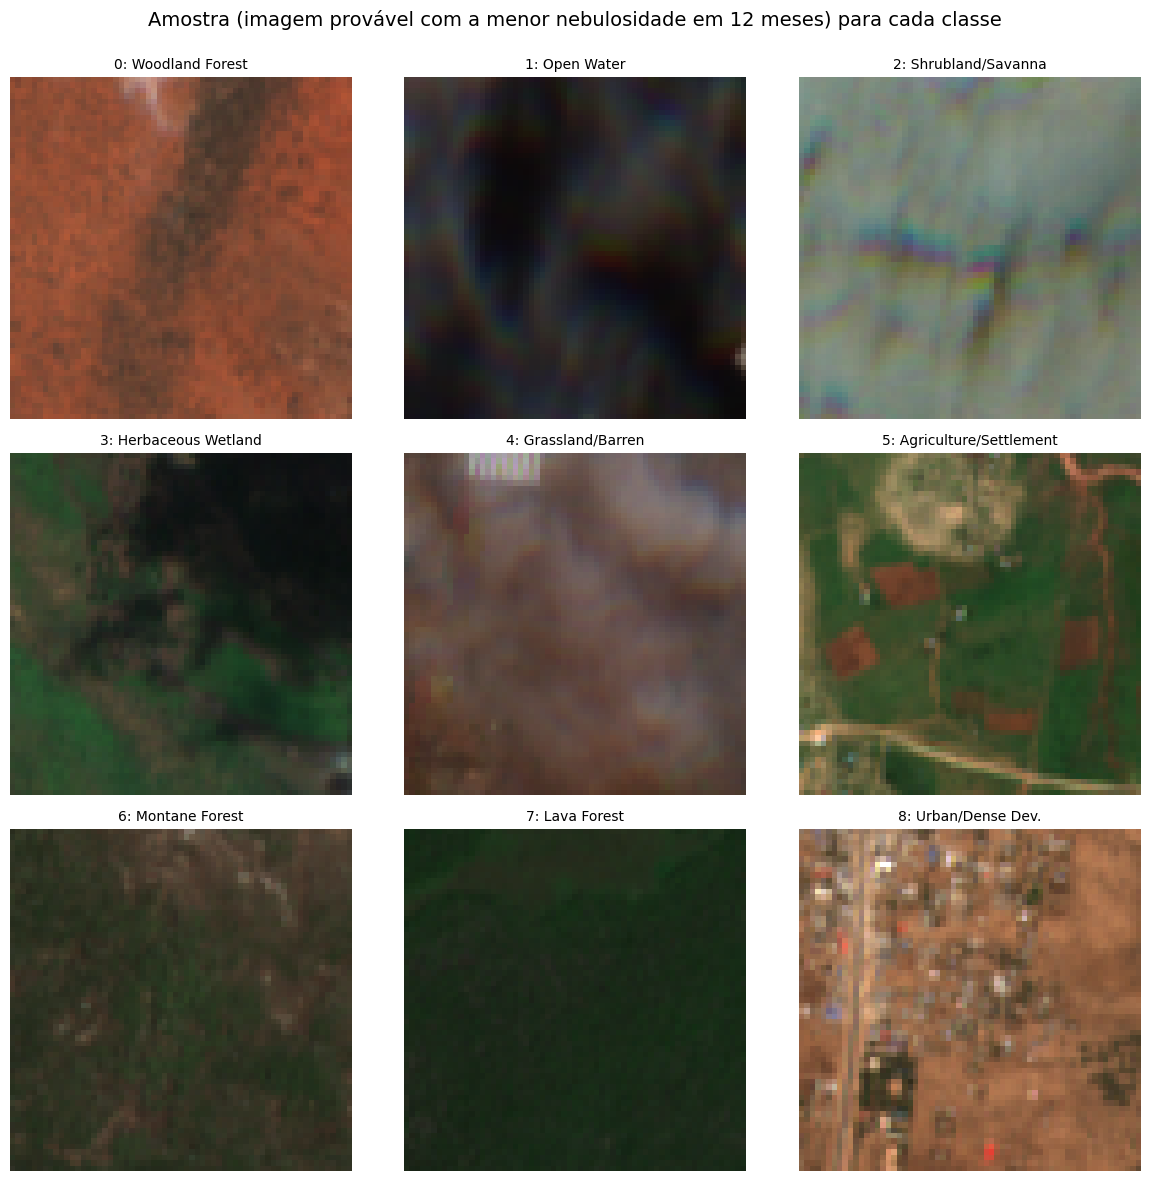

In [ ]:
def load_rgb_image(window, dataset_path, timestep=0):
    """Lê uma composição RGB (B04 - red, B03 - green, B02 - blue) de uma janela."""
    window_root = window.get_window_root(dataset_path, window.group, window.name)
    layer_name = "sentinel2" if timestep == 0 else f"sentinel2.{timestep}"
    rgb_path = window_root / "layers" / layer_name / "B02_B03_B04_B08" / "geotiff.tif"

    if not rgb_path.exists():
        return None

    with rasterio.open(str(rgb_path)) as src:
        # As bandas são B02, B03, B04, B08 e nós queremos B04, B03, B02 (RGB)
        data = src.read()  # (4, H, W)
        rgb = data[[2, 1, 0], :, :]  # B04, B03, B02

    # Normaliza para visualizaçã: divide por 3000 para comparação entre imagens
    # (escalonamento padrão de reflectância do Sentinel-2: evita a normalização por percentil da imagem)
    rgb = np.clip(rgb.astype(np.float32) / 3000, 0, 1)

    return rgb.transpose(1, 2, 0)  # (H, W, 3)

def find_least_cloudy_timestep(window, dataset_path, num_timesteps=12):
    """Find the least cloudy timestep for a window (based on high reflectance pixels)."""
    best_timestep = num_timesteps - 1  # Default to last (often dry season, less cloudy)
    min_cloud_score = float('inf')

    for t in range(num_timesteps):
        window_root = window.get_window_root(dataset_path, window.group, window.name)
        layer_name = "sentinel2" if t == 0 else f"sentinel2.{t}"
        rgb_path = window_root / "layers" / layer_name / "B02_B03_B04_B08" / "geotiff.tif"

        if not rgb_path.exists():
            continue

        with rasterio.open(str(rgb_path)) as src:
            data = src.read()
            # Métrica de nuvem: contagem de pixels em que o valor mínimo da banda é > 2000 (brilho = provável presença de nuvem)
            cloud_score = np.count_nonzero(data.min(axis=0) > 2000) # Altere se preferir o valor 2000
            if cloud_score < min_cloud_score:
                min_cloud_score = cloud_score
                best_timestep = t

    return best_timestep

# Agrupa as janelas por classe
class_windows = {i: [] for i in range(NUM_CLASSES)}
for w in train_windows:
    label = get_label_from_window(w, DATASET_PATH)
    if label is not None and label < NUM_CLASSES:
        class_windows[label].append(w)

# Exibe uma amostra por classe (selecionando entre as 12 imagens (timestep) com a menor cobertura de nuvens/nebulosidade)
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for cls_id in range(NUM_CLASSES):
    ax = axes[cls_id]
    if class_windows[cls_id]:
        window = class_windows[cls_id][0]
        # Encontra a imagem, entre as 12 disponíveis (uma por mês), com a menor nebulosidade
        best_t = find_least_cloudy_timestep(window, DATASET_PATH)
        rgb = load_rgb_image(window, DATASET_PATH, timestep=best_t)
        if rgb is not None:
            ax.imshow(rgb)
            ax.set_title(f"{cls_id}: {CLASS_NAMES[cls_id]}", fontsize=10)
        else:
            ax.text(0.5, 0.5, "No image", ha='center', va='center')
    else:
        ax.text(0.5, 0.5, "No samples", ha='center', va='center')
    ax.axis('off')

plt.suptitle("Amostra (imagem provável com a menor nebulosidade em 12 meses) para cada classe\n", fontsize=14)
plt.tight_layout()
plt.show()

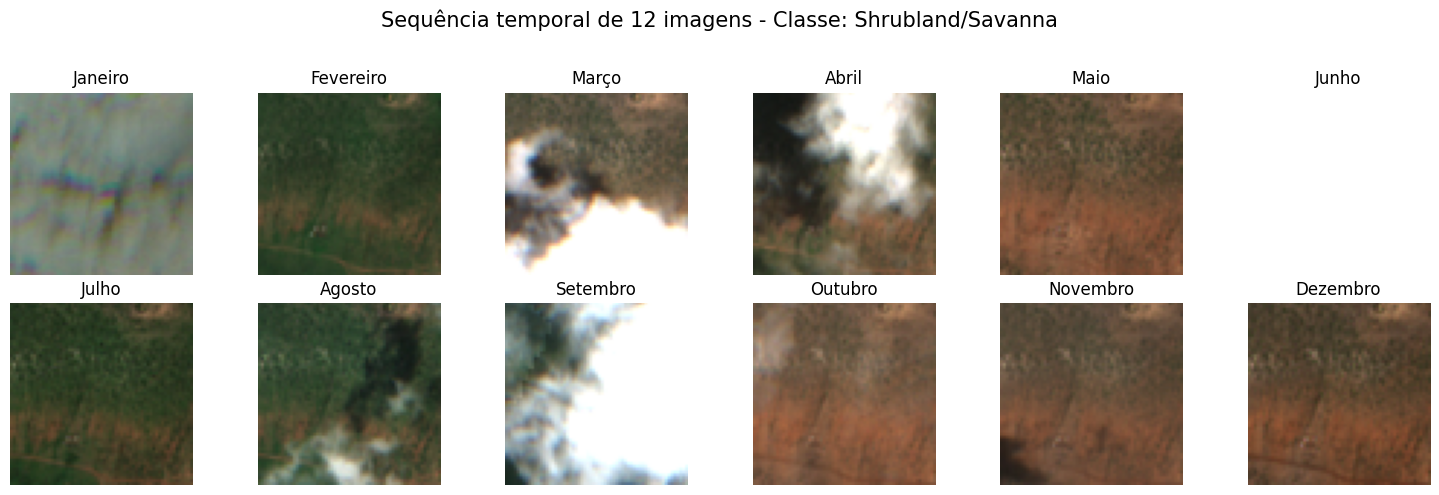

In [ ]:
# Exibe a sequência temporal de 12 imagens para uma amostra
sample_window = train_windows[0]

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
axes = axes.flatten()

month = ["Janeiro","Fevereiro","Março","Abril","Maio","Junho",
         "Julho","Agosto","Setembro","Outubro","Novembro","Dezembro"]

#for t in range(12):
for t, mes in enumerate (month):
    ax = axes[t]
    rgb = load_rgb_image(sample_window, DATASET_PATH, timestep=t)
    if rgb is not None:
        ax.imshow(rgb)
        ax.set_title(f"{mes}", fontsize=12)
    else:
        ax.text(0.5, 0.5, "Missing", ha='center', va='center', fontsize=8)
    ax.axis('off')

label = get_label_from_window(sample_window, DATASET_PATH)
plt.suptitle(f"Sequência temporal de 12 imagens - Classe: {CLASS_NAMES[label]}\n", fontsize=15)
plt.tight_layout()
plt.show()

---
## 4. Usando OlmoEarth *Embeddings* (sem *fine-tuning*)

Nessa seção, iremos:
1. Carregar o modelo **Nano** pré-treinado do OlmoEarth
2. Extrair os *embeddings* de todas as amostras
3. Treinar classificadores simples sobre essa base

Essa abordagem é **rápida** e requer **o mínimo de GPU**, tornando o experimento ideal para prototipagem rápida.

### 4.1 Carregar o modelo do OlmoEarth

Os modelos do OlmoEarth estão disponíveis em vários tamanhos. Usaremos o **Nano** (1,4 milhão de parâmetros) para este tutorial, mas a mesma abordagem funciona com modelos maiores e pode ser testada para aumentar a acurácia.

In [ ]:
# Carregar o modelo OlmoEarth Nano com pesos pré-treinados do HuggingFace
print("Carregando o modelo Nano do OlmoEarth...")
print("Pesos pré-treindos do: allenai/OlmoEarth-v1-Nano\n")

model = load_model_from_id(ModelID.OLMOEARTH_V1_NANO)
model.eval()
encoder = model.encoder.to(device)

num_params = sum(p.numel() for p in encoder.parameters())
print(f"\nModelo carregado!")
print(f"  Parâmetros: {num_params:,} ({num_params/1e6:.1f}M)")
print(f"  Dimensão dos embeddings: 128")
print(f"  Dispositivo: {device}")

Carregando o modelo Nano do OlmoEarth...
Pesos pré-treindos do: allenai/OlmoEarth-v1-Nano



/usr/lib/python3.13/importlib/__init__.py:88: FutureWarning: The 'helios' package has been renamed to 'olmoearth_pretrain'. Please update your imports; this compatibility shim will be removed in a future release.
  return _bootstrap._gcd_import(name[level:], package, level)



Modelo carregado!
  Parâmetros: 1,361,024 (1.4M)
  Dimensão dos embeddings: 128
  Dispositivo: cuda


### 4.2 Definir funções de carregamento de dados e de extração de *embeddings*

In [ ]:
# Carrega a configuração de normalização do OlmoEarth (média/desvio padrão por banda)
NORM_CONFIG = load_computed_config()['sentinel2_l2a']

# Id das bandas na ordem em que aparecem nos dados empilhados (bandas com resolução de 10 m, 20 m e 60 m)
BAND_NAMES = ["B02", "B03", "B04", "B08", "B05", "B06", "B07", "B8A", "B11", "B12", "B01", "B09"]

def normalize_sentinel2(data, std_multiplier=2):
    """Aplica a normalização do OlmoEarth nas imagens do Sentinel-2."""
    data = data.astype(np.float32).copy()
    T, C, H, W = data.shape
    for t in range(T):
        for c, band_name in enumerate(BAND_NAMES):
            if band_name in NORM_CONFIG:
                mean = NORM_CONFIG[band_name]['mean']
                std = NORM_CONFIG[band_name]['std']
                min_val = mean - std_multiplier * std
                max_val = mean + std_multiplier * std
                data[t, c] = (data[t, c] - min_val) / (max_val - min_val)
    return np.clip(data, 0, 1)

def load_window_data(window, dataset_path, max_timesteps=12, normalize=True):
    """Carrega os dados do Sentinel-2 e rótulo de uma janela

    Retorna:
        s2_data: numpy array com shape (T, 12, H, W) com todas as bandas do Sentinel-2 (normalizadas se normalize=True)
        label: tipo integer
    """
    window_root = window.get_window_root(dataset_path, window.group, window.name)
    layers_dir = window_root / "layers"

    all_timesteps = []

    for t in range(max_timesteps):
        layer_name = "sentinel2" if t == 0 else f"sentinel2.{t}"
        layer_dir = layers_dir / layer_name

        if not layer_dir.exists():
            continue

        # Carrega e reamostra todas as bandas para uma mesma resolução espacial
        bandset_data = []
        target_size = None

        for bandset_name, n_bands in BANDSET_INFO:
            path = layer_dir / bandset_name / "geotiff.tif"
            if path.exists():
                with rasterio.open(str(path)) as src:
                    data = src.read()  # (C, H, W)
                    if target_size is None:
                        target_size = data.shape[1:]
                    # Reamostre para a resolução alvo se necessário
                    if data.shape[1:] != target_size:
                        factors = (1, target_size[0]/data.shape[1], target_size[1]/data.shape[2])
                        data = zoom(data, factors, order=1)
                    bandset_data.append(data)

        if len(bandset_data) == 3:
            combined = np.concatenate(bandset_data, axis=0)  # (12, H, W)
            all_timesteps.append(combined)

    if not all_timesteps:
        return None, None

    s2_data = np.stack(all_timesteps, axis=0)  # (T, 12, H, W) - aqui possui quatro dimensões: tempo, canal, altura, largura

    # Aplica a normalização do OlmoEarth
    if normalize:
        s2_data = normalize_sentinel2(s2_data)

    # Carrega o rótulo se o rótulo for válido e não nodata
    label_path = layers_dir / "label" / "category" / "geotiff.tif"
    if label_path.exists():
        with rasterio.open(str(label_path)) as src:
            label = src.read(1)
            unique = np.unique(label)
            valid_labels = unique[(unique != NODATA_VALUE) & (unique < NUM_CLASSES)]
            if len(valid_labels) > 0:
                center_label = int(valid_labels[0])
            else:
                center_label = None
    else:
        center_label = None

    return s2_data, center_label

In [ ]:
def extract_embedding(encoder, s2_data, device, patch_size=4):
    """Extração de embeddings do Sentinel-2 usando OlmoEarth

    Args:
        encoder: encoder (codificador) do OlmoEarth do modelo carregado
        s2_data: numpy array com shape (T, 12, H, W)
        dispositivo: torch device
        patch_size: tamanho de patch que será input do encoder

    Returns:
        embeddings: numpy array com shape (128,)

    """

    T, C, H, W = s2_data.shape # Input (imagens Sentinel-2)

    # Converte para tensor
    s2_tensor = torch.from_numpy(s2_data.astype(np.float32)).to(device)

    # Reorganiza o tensor para o formato do OlmoEarth: (B, H, W, T, C) - batch, height, width, time, channel
    s2_tensor = rearrange(s2_tensor, 't c h w -> 1 h w t c')

    # Cria máscara para 3 conjuntos de bandas
    mask = torch.full((1, H, W, T, 3), MaskValue.ONLINE_ENCODER.value,
                      dtype=torch.int32, device=device)

    # Timestamps (meses 0-11) - começa no índice 0
    timestamps = torch.zeros((1, T, 3), dtype=torch.int32, device=device)
    timestamps[0, :, 1] = torch.arange(T, device=device)  # mes

    sample = MaskedOlmoEarthSample(
        sentinel2_l2a=s2_tensor,
        sentinel2_l2a_mask=mask,
        timestamps=timestamps
    )

    with torch.no_grad():
        output = encoder(sample, fast_pass=True, patch_size=patch_size)
        tokens = output['tokens_and_masks'].sentinel2_l2a
        embedding = tokens.mean(dim=[1, 2, 3, 4])  # Agrupar em (B, C)

    return embedding.float().cpu().numpy()[0]

### 4.3 Extração de *embeddings*

In [ ]:
# Extrai os embeddings de todas as amostras
# Esse procedimento demora mais de dois minutos com o GPU T4 do Colab

print("Extraindo embeddings das amostras do conjunto de treinamento...")
train_embeddings = []
train_labels = []

for window in tqdm(train_windows, desc="Train"):
    s2_data, label = load_window_data(window, DATASET_PATH)
    if s2_data is None or label is None or label >= NUM_CLASSES:
        continue
    try:
        emb = extract_embedding(encoder, s2_data, device)
        train_embeddings.append(emb)
        train_labels.append(label)
    except Exception as e:
        continue

train_embeddings = np.array(train_embeddings)
train_labels = np.array(train_labels)
print(f"Treinamento: {len(train_embeddings)} amostras, shape {train_embeddings.shape}")

print("\nExtraindo embeddings das amostras do conjunto de validação...")
val_embeddings = []
val_labels = []

for window in tqdm(val_windows, desc="Val"):
    s2_data, label = load_window_data(window, DATASET_PATH)
    if s2_data is None or label is None or label >= NUM_CLASSES:
        continue
    try:
        emb = extract_embedding(encoder, s2_data, device)
        val_embeddings.append(emb)
        val_labels.append(label)
    except Exception as e:
        continue

val_embeddings = np.array(val_embeddings)
val_labels = np.array(val_labels)
print(f"Val: {len(val_embeddings)} amostras, shape {val_embeddings.shape}")

Extraindo embeddings das amostras do conjunto de treinamento...


Train:   0%|          | 0/1115 [00:00<?, ?it/s]

Treinamento: 1115 amostras, shape (1115, 128)

Extraindo embeddings das amostras do conjunto de validação...


Val:   0%|          | 0/344 [00:00<?, ?it/s]

Val: 344 amostras, shape (344, 128)


### 4.4 Treinamento de classificadores simples usando os *embeddings*

In [ ]:
# Normaliza os embeddings usando StandardScaler (para o Linear Probe)
import warnings
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_emb_scaled = scaler.fit_transform(train_embeddings)
val_emb_scaled = scaler.transform(val_embeddings)

# Substitui valores NaN/inf de features com variância zero após a normalização
train_emb_scaled = np.nan_to_num(train_emb_scaled, nan=0.0, posinf=0.0, neginf=0.0)
val_emb_scaled = np.nan_to_num(val_emb_scaled, nan=0.0, posinf=0.0, neginf=0.0)

# Cria versões normalizadas com L2 para um classificador kNN (cosine similarity)
train_emb_norm = preprocessing.normalize(train_embeddings, norm='l2')
val_emb_norm = preprocessing.normalize(val_embeddings, norm='l2')

# Treina o kNN (abordagem não supervisionada)
print("Treinando um classificador KNN (k=20, cosine similarity)...")
k = min(20, len(train_embeddings))
knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')
knn.fit(train_emb_norm, train_labels)

knn_preds = knn.predict(val_emb_norm)
knn_accuracy = accuracy_score(val_labels, knn_preds)
print(f"Acurácia com o kNN: {knn_accuracy:.1%}")

# Treina o linear probe com os embeddings normalizados (scaled)
print("\nTreinando com Linear Probe (logistic regression)...")
lp = LogisticRegression(max_iter=1000, solver='lbfgs')
lp.fit(train_emb_scaled, train_labels)

lp_preds = lp.predict(val_emb_scaled)
lp_accuracy = accuracy_score(val_labels, lp_preds)
print(f"Acurácia com o Linear Probe: {lp_accuracy:.1%}")

Treinando um classificador KNN (k=20, cosine similarity)...
Acurácia com o kNN: 71.5%

Treinando com Linear Probe (logistic regression)...
Acurácia com o Linear Probe: 68.3%


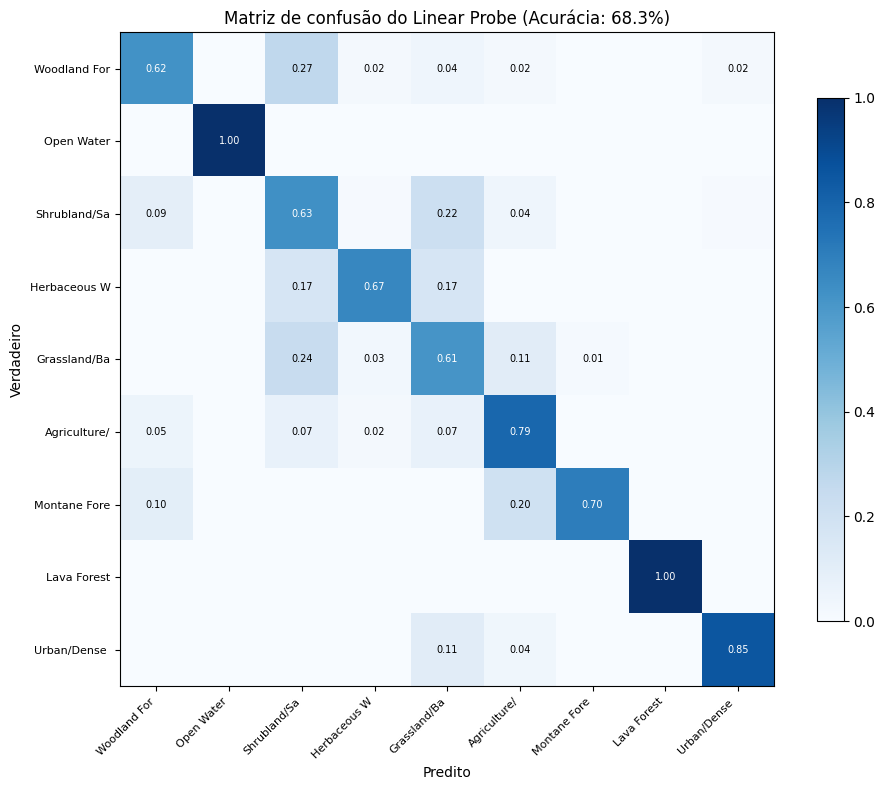

In [ ]:
# Exibe a matriz de confusão do Linear Probe
cm = confusion_matrix(val_labels, lp_preds)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)

ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels([c[:12] for c in CLASS_NAMES], rotation=45, ha='right', fontsize=8)
ax.set_yticklabels([c[:12] for c in CLASS_NAMES], fontsize=8)
ax.set_xlabel("Predito")
ax.set_ylabel("Verdadeiro")
ax.set_title(f"Matriz de confusão do Linear Probe (Acurácia: {lp_accuracy:.1%})")

# Adicione anotações textuais
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if cm_norm[i, j] > 0.01:  # Only show if > 1%
            color = 'white' if cm_norm[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                   color=color, fontsize=7)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

In [ ]:
# Exibe um resumo dos resultados obtidos
print("="*50)
print("Resultados baseados em embeddings (sem fine-tuning)")
print("="*50)
print(f"Amostras de treinamento: {len(train_embeddings)}")
print(f"Amostras de validação: {len(val_embeddings)}")
print(f"Dimensão dos embeddings: {train_embeddings.shape[1]}")
print(f"\nAcurácia do kNN (k={k}):     {knn_accuracy:.1%}")
print(f"Acurácia do Linear Probe: {lp_accuracy:.1%}")

Resultados baseados em embeddings (sem fine-tuning)
Amostras de treinamento: 1115
Amostras de validação: 344
Dimensão dos embeddings: 128

Acurácia do kNN (k=20):     71.5%
Acurácia do Linear Probe: 68.3%


### 4.5 Visualização de predições da classificação

Vamos ver como nosso classificador baseado em *embeddings* se sai em imagens completas, gerando mapas de segmentação por *patch*.

Gerando predições sobre as janelas...


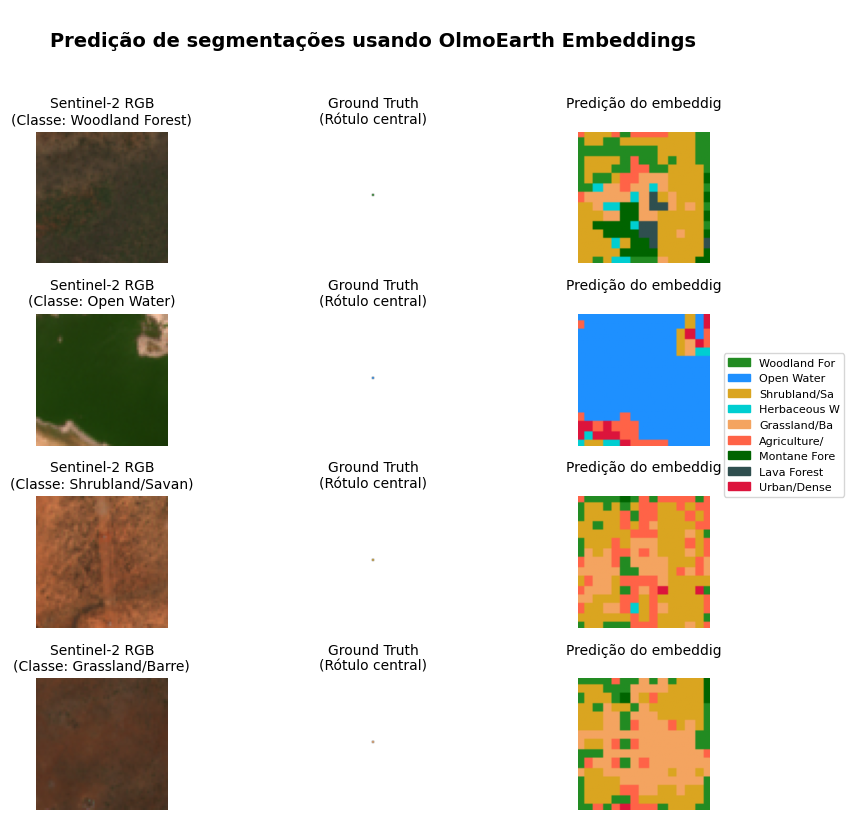

In [ ]:
# Visualizar as predições nos dados de validação
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# Use CLASS_COLORS definido anteriormente
cmap = ListedColormap(CLASS_COLORS)

# Seleciona janelas de validação de diferentes classes
demo_classes = [0, 1, 2, 4]  # Woodland, Water, Shrubland, Grassland
demo_windows = []
for cls_id in demo_classes:
    cls_windows = [w for w in val_windows if get_label_from_window(w, DATASET_PATH) == cls_id]
    if cls_windows:
        demo_windows.append((cls_windows[0], cls_id))

print(f"Gerando predições sobre as janelas...")

def predict_segmentation(encoder, s2_data, classifier, scaler, output_shape, device):
    """Gera segmentações por patch (predições) usando embeddings."""
    T, C, H, W = s2_data.shape
    s2_tensor = torch.from_numpy(s2_data.astype(np.float32)).to(device)
    s2_tensor = rearrange(s2_tensor, 't c h w -> 1 h w t c')

    mask = torch.full((1, H, W, T, 3), MaskValue.ONLINE_ENCODER.value, dtype=torch.int32, device=device)
    timestamps = torch.zeros((1, T, 3), dtype=torch.int32, device=device)
    timestamps[0, :, 1] = torch.arange(T, device=device)

    sample = MaskedOlmoEarthSample(sentinel2_l2a=s2_tensor, sentinel2_l2a_mask=mask, timestamps=timestamps)

    with torch.no_grad():
        output = encoder(sample, fast_pass=True, patch_size=4)
        tokens = output['tokens_and_masks'].sentinel2_l2a.mean(dim=(3, 4))  # (B, H_p, W_p, C)

    patch_embs = tokens.float().cpu().numpy()[0]
    H_p, W_p, C_emb = patch_embs.shape

    # Predição para cada patch
    embs_flat = patch_embs.reshape(-1, C_emb)
    embs_scaled = scaler.transform(embs_flat)
    preds = classifier.predict(embs_scaled).reshape(H_p, W_p)

    # Aumenta a resolução para o tamanho de saída
    from scipy.ndimage import zoom
    scale_h = output_shape[0] / H_p
    scale_w = output_shape[1] / W_p
    return zoom(preds.astype(float), (scale_h, scale_w), order=0).astype(int)

# Cria visualização - 3 colunas: RGB, Ground Truth (rótulo central), Predição (do embedding)
fig, axes = plt.subplots(len(demo_windows), 3, figsize=(9, 2 * len(demo_windows)))
if len(demo_windows) == 1:
    axes = axes.reshape(1, -1)

for i, (window, true_label) in enumerate(demo_windows):
    # Use o último intervalo temporal (geralmente na estação seca, com menos nebulosidade) para uma visualização mais nítida
    rgb = load_rgb_image(window, DATASET_PATH, timestep=11)
    if rgb is None:  # Fallback para qualquer outro mês da janela
        rgb = load_rgb_image(window, DATASET_PATH, timestep=0)
    s2_data, _ = load_window_data(window, DATASET_PATH)

    # Carrega mapa de rótulos de referência (ground truth)
    window_root = window.get_window_root(DATASET_PATH, window.group, window.name)
    label_path = window_root / "layers" / "label" / "category" / "geotiff.tif"
    with rasterio.open(str(label_path)) as src:
        label_map = src.read(1)

    # Obtém a predição
    pred_map = predict_segmentation(encoder, s2_data, lp, scaler, label_map.shape, device)

    # Coluna 1: RGB
    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title(f"Sentinel-2 RGB\n(Classe: {CLASS_NAMES[true_label][:15]})", fontsize=10)
    axes[i, 0].axis('off')

    # Coluna 2: Ground truth (com rótulo central)
    masked_labels = np.ma.masked_where(label_map >= len(CLASS_NAMES), label_map)
    axes[i, 1].imshow(masked_labels, cmap=cmap, vmin=0, vmax=len(CLASS_NAMES)-1)
    h, w = label_map.shape
    circle = plt.Circle((w//2, h//2), 3, color='white', fill=False, linewidth=2)
    axes[i, 1].add_patch(circle)
    axes[i, 1].set_title("Ground Truth\n(Rótulo central)", fontsize=10)
    axes[i, 1].axis('off')

    # Coluna 3: Predição do embedding (com 128 valores)
    axes[i, 2].imshow(pred_map, cmap=cmap, vmin=0, vmax=len(CLASS_NAMES)-1)
    axes[i, 2].set_title("Predição do embeddig\n", fontsize=10)
    axes[i, 2].axis('off')

# Adiciona legenda
patches = [mpatches.Patch(color=CLASS_COLORS[i], label=CLASS_NAMES[i][:12]) for i in range(len(CLASS_NAMES))]
fig.legend(handles=patches, loc='center right', bbox_to_anchor=(1.03, 0.5), fontsize=8)
plt.suptitle("\nPredição de segmentações usando OlmoEarth Embeddings", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Fine-tuning

Vamos fazer um *fine-tuning* no modelo no intuito de melhorarmos a acurácia usando o *pipeline* de treinamento.

O *fine-tuning* envolve:
  1. Adicionar um *head* de segmentação após o encoder (codificador)
  2. Treinar de ponta a ponta com perda de entropia cruzada
  3. Usar *scheduling* na taxa de aprendizado (*learning rate*) e congelamento do encoder para garantir estabilidade



In [ ]:
# Limpa a memória da GPU utilizada no processamento anterior
# (é seguro executar novamente, mesmo que essas variáveis já tenham sido excluídas)
for _var in ['encoder', 'model']:
    if _var in dir():
        del globals()[_var]
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("GPU pronta para o fine-tuning")

GPU pronta para o fine-tuning


In [ ]:
# Configurando os parâmetros do fine-tuning
# O treinamento é dividido em duas etapas:
#   1. FREEZE_EPOCHS: treina apenas o decoder (encoder frozen - mantém o encoder congelado/fixo)
#   2. UNFREEZE_EPOCHS: treina o modelo completo (encoder unfrozen - descongela os pesos do encoder)

# Default: 2 + 2 = 4 épocas (aproximadamente 20 minutos com o T4 do Colab)
# Para melhorar a acurácia, aumente para 5 + 25 = 30 épocas (aproximadamente 3 horas usando T4)
FREEZE_EPOCHS = 5    # Épocas com o encoder travado (treina apenas o decoder)
UNFREEZE_EPOCHS = 25  # Épocas com o encoder destravado (treina o modelo completo)
NUM_EPOCHS = FREEZE_EPOCHS + UNFREEZE_EPOCHS

print(f"Configuração do treinamento:")
print(f"  Épocas (freeze encoder):   {FREEZE_EPOCHS} (apenas decoder)")
print(f"  Épocas (unfreeze encoder): {UNFREEZE_EPOCHS} (modelo completo)")
print(f"  Total de épocas:    {NUM_EPOCHS}")

# Create fine-tuning configuration
finetune_config = f'''
model:
  class_path: rslearn.train.lightning_module.RslearnLightningModule
  init_args:
    model:
      class_path: rslearn.models.multitask.MultiTaskModel
      init_args:
        encoder:
          - class_path: rslearn.models.olmoearth_pretrain.model.OlmoEarth
            init_args:
              model_id: OLMOEARTH_V1_NANO
              patch_size: 4
        decoders:
          segment:
            - class_path: rslearn.models.upsample.Upsample
              init_args:
                scale_factor: 4
            - class_path: rslearn.models.conv.Conv
              init_args:
                in_channels: 128
                out_channels: 10
                kernel_size: 1
                activation:
                  class_path: torch.nn.Identity
            - class_path: rslearn.train.tasks.segmentation.SegmentationHead
    lr: 0.0001
    plateau: true
    plateau_factor: 0.2
    plateau_patience: 2
data:
  class_path: rslearn.train.data_module.RslearnDataModule
  init_args:
    path: data/dataset
    inputs:
      sentinel2_l2a:
        data_type: raster
        layers: [sentinel2]
        bands: [B02, B03, B04, B08, B05, B06, B07, B8A, B11, B12, B01, B09]
        passthrough: true
        dtype: FLOAT32
        load_all_item_groups: true
        load_all_layers: true
      label:
        data_type: raster
        layers: [label]
        bands: [category]
        is_target: true
        dtype: INT32
    task:
      class_path: rslearn.train.tasks.multi_task.MultiTask
      init_args:
        tasks:
          segment:
            class_path: rslearn.train.tasks.segmentation.SegmentationTask
            init_args:
              num_classes: 10
              zero_is_invalid: false
              nodata_value: 9
        input_mapping:
          segment:
            label: targets
    batch_size: 4
    num_workers: 4
    default_config:
      transforms:
        - class_path: rslearn.train.transforms.pad.Pad
          init_args:
            size: 31
            mode: center
            image_selectors: [sentinel2_l2a, target/segment/classes, target/segment/valid]
        - class_path: rslearn.train.transforms.crop.Crop
          init_args:
            crop_size: 16
            image_selectors: [sentinel2_l2a, target/segment/classes, target/segment/valid]
        - class_path: rslearn.models.olmoearth_pretrain.norm.OlmoEarthNormalize
          init_args:
            band_names:
              sentinel2_l2a: [B02, B03, B04, B08, B05, B06, B07, B8A, B11, B12, B01, B09]
    train_config:
      transforms:
        - class_path: rslearn.train.transforms.pad.Pad
          init_args:
            size: 31
            mode: center
            image_selectors: [sentinel2_l2a, target/segment/classes, target/segment/valid]
        - class_path: rslearn.train.transforms.crop.Crop
          init_args:
            crop_size: 16
            image_selectors: [sentinel2_l2a, target/segment/classes, target/segment/valid]
        - class_path: rslearn.train.transforms.flip.Flip
          init_args:
            image_selectors: [sentinel2_l2a, target/segment/classes, target/segment/valid]
        - class_path: rslearn.models.olmoearth_pretrain.norm.OlmoEarthNormalize
          init_args:
            band_names:
              sentinel2_l2a: [B02, B03, B04, B08, B05, B06, B07, B8A, B11, B12, B01, B09]
      groups: [spatial_split]
      tags:
        split: train
    val_config:
      groups: [spatial_split]
      tags:
        split: val
trainer:
  max_epochs: {NUM_EPOCHS}
  accelerator: gpu
  devices: 1
  log_every_n_steps: 10
  enable_progress_bar: true
  callbacks:
    - class_path: lightning.pytorch.callbacks.ModelCheckpoint
      init_args:
        dirpath: checkpoints
        save_top_k: 1
        save_last: true
        monitor: val_segment/accuracy
        mode: max
    - class_path: lightning.pytorch.callbacks.TQDMProgressBar
      init_args:
        refresh_rate: 10
    - class_path: rslearn.train.callbacks.freeze_unfreeze.FreezeUnfreeze
      init_args:
        module_selector: [model, encoder, 0]
        unfreeze_at_epoch: {FREEZE_EPOCHS}
        unfreeze_lr_factor: 10
'''

with open('finetune_config.yaml', 'w') as f:
    f.write(finetune_config)
print("\nConfiguração do fine-tuning salva em finetune_config.yaml")

Configuração do treinamento:
  Épocas (freeze encoder):   5 (apenas decoder)
  Épocas (unfreeze encoder): 25 (modelo completo)
  Total de épocas:    30

Configuração do fine-tuning salva em finetune_config.yaml


In [ ]:
# Roda o fine-tuning
# Default (2 + 2 = 4 épocas) - rápido
# Full training (5 + 25 = 30 épocas) - mais demorado
!pip install git+https://github.com/allenai/olmoearth_pretrain_minimal.git
import subprocess
import sys

print("="*60)
print("INICIANDO O FINE-TUNING")
print("="*60)
print(f"Total de épocas: {NUM_EPOCHS}")
print(f"  Fase 1: {FREEZE_EPOCHS} épocas (encoder frozen)")
print(f"  Fase 2: {UNFREEZE_EPOCHS} épocas (encoder unfrozen)")
print("-"*60)
print("Você deverá ver barras de progresso para cada época abaixo...")
print("-"*60 + "\n")

# Run training with real-time output
process = subprocess.Popen(
    ["rslearn", "model", "fit", "--config", "finetune_config.yaml"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    env={**os.environ, "WANDB_MODE": "disabled", "PYTHONUNBUFFERED": "1", "MPLBACKEND": "agg"}
)

training_output_lines = []
for line in process.stdout:
    print(line, end='')  # Exibe o output em tempo real
    training_output_lines.append(line)

process.wait()
training_output = ''.join(training_output_lines)

print("\n" + "="*60)
if process.returncode == 0:
    print("FINE-TUNING FOI CONCLUÍDO COM SUCESSO!")
else:
    print(f"FINE-TUNING FALHOU (código de saída: {process.returncode})")
print("="*60)

  Cloning https://github.com/allenai/olmoearth_pretrain_minimal.git to /tmp/pip-req-build-41stnd0y
  Running command git clone --filter=blob:none --quiet https://github.com/allenai/olmoearth_pretrain_minimal.git /tmp/pip-req-build-41stnd0y
  Resolved https://github.com/allenai/olmoearth_pretrain_minimal.git to commit 28eb18a852be74871a357fbcca7676f790a55c66
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INICIANDO O FINE-TUNING
Total de épocas: 30
  Fase 1: 5 épocas (encoder frozen)
  Fase 2: 25 épocas (encoder unfrozen)
------------------------------------------------------------
Você deverá ver barras de progresso para cada época abaixo...
------------------------------------------------------------

format=2026-09-18 19:23:20,794 loglevel=INFO   logger=rslearn.main main() L1112 Using multiprocessing context: <multiprocessing.context.ForkServerContext object at 0x78235a970c20>
/usr/local/lib/python

In [ ]:
# Avaliando o modelo final
import re

# Encontra o melhor checkpoint do treinamento
best_ckpt = "checkpoints/last.ckpt"
if os.path.exists("checkpoints"):
    ckpts = [f for f in os.listdir("checkpoints") if f.endswith(".ckpt") and f != "last.ckpt"]
    if ckpts:
        best_ckpt = f"checkpoints/{ckpts[0]}"

print(f"Avaliando checkpoint {best_ckpt}")

# Roda a valiação com base no checkpoint encontrado
validate_process = subprocess.Popen(
    ["rslearn", "model", "validate", "--config", "finetune_config.yaml", "--ckpt_path", best_ckpt],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    env={**os.environ, "WANDB_MODE": "disabled", "MPLBACKEND": "agg"}
)

validate_output_lines = []
for line in validate_process.stdout:
    print(line, end='')
    validate_output_lines.append(line)
validate_process.wait()
validate_output = ''.join(validate_output_lines)

# Avaliação da acurácia do conjunto de validação
finetune_accuracy = None
for pattern in [r'val_segment/accuracy\s+([0-9.]+)', r'val_segment/accuracy[:\s│\|]+([0-9.]+)']:
    match = re.search(pattern, validate_output)
    if match:
        finetune_accuracy = float(match.group(1))
        break

print("\n" + "="*50)
print("RESULTADOS DO FINE-TUNING")
print("="*50)
print(f"Checkpoint: {best_ckpt}")
if finetune_accuracy is not None:
    print(f"Acurácia de validação: {finetune_accuracy:.1%}")
else:
    print("Não foi possível avaliar a acurácia. Verifique a saída acima para 'val_segment/accuracy'.")
print("="*50)

Avaliando checkpoint checkpoints/epoch=25-step=7254.ckpt
format=2026-09-18 20:36:06,801 loglevel=INFO   logger=rslearn.main main() L1112 Using multiprocessing context: <multiprocessing.context.ForkServerContext object at 0x7e38ff828c20>
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/cli.py:553: LightningCLI's args parameter is intended to run from within Python like if it were from the command line. To prevent mistakes it is not recommended to provide both args and command line arguments, got: sys.argv[1:]=['model', 'validate', '--config', 'finetune_config.yaml', '--ckpt_path', 'checkpoints/epoch=25-step=7254.ckpt'], args=['validate', '--config', 'finetune_config.yaml', '--ckpt_path', 'checkpoints/epoch=25-step=7254.ckpt'].
/usr/local/lib/python3.13/dist-packages/lightning/fabric/utilities/seed.py:44: No seed found, seed set to 0
Seed set to 0
/usr/local/lib/python3.13/dist-packages/rslearn/models/olmoearth_pretrain/model.py:146: FutureWarning: For new projects, don't use le

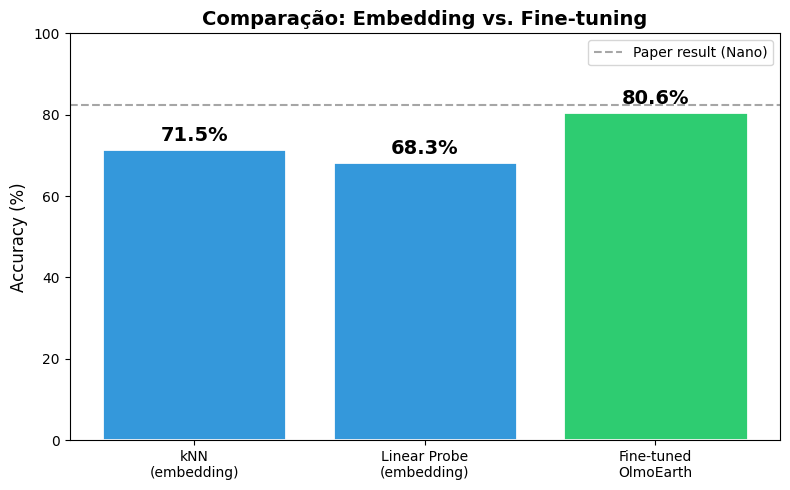


O fine-tuning melhorou a acurácia em 9.1% se comparado com o método dos embeddings!


In [ ]:
# Comparação das acurácias por abordagem
methods = ['kNN\n(embedding)', 'Linear Probe\n(embedding)', 'Fine-tuned\nOlmoEarth']
accuracies = [knn_accuracy, lp_accuracy, finetune_accuracy if finetune_accuracy else 0]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#3498db', '#3498db', '#2ecc71']
bars = ax.bar(methods, [a * 100 for a in accuracies], color=colors, edgecolor='white', linewidth=2)

# Adicionar rótulos de valor nas barras
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{acc:.1%}', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Comparação: Embedding vs. Fine-tuning', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
ax.axhline(y=82.5, color='gray', linestyle='--', alpha=0.7, label='Paper result (Nano)')
ax.legend()

plt.tight_layout()
plt.show()

if finetune_accuracy:
    improvement = finetune_accuracy - max(knn_accuracy, lp_accuracy)
    print(f"\nO fine-tuning melhorou a acurácia em {improvement:.1%} se comparado com o método dos embeddings!")

### Comparação das segmentações: *Embeddings* *vs*. *Fine-tuning*

Agora vamos comparar as predições das duas abordagens: a primeira, que se baseia na classificação com os *embeddings*, e a segunda, que envolve *fine-tuning* do modelo.

Carregando o encoder pré-treinado para comparação de embeddings...
  Encoder pré-treinado carregado
Carregando o modelo com fine-tuning do checkpoint: checkpoints/epoch=25-step=7254.ckpt
  Carregado 102 encoder weights + decoder head


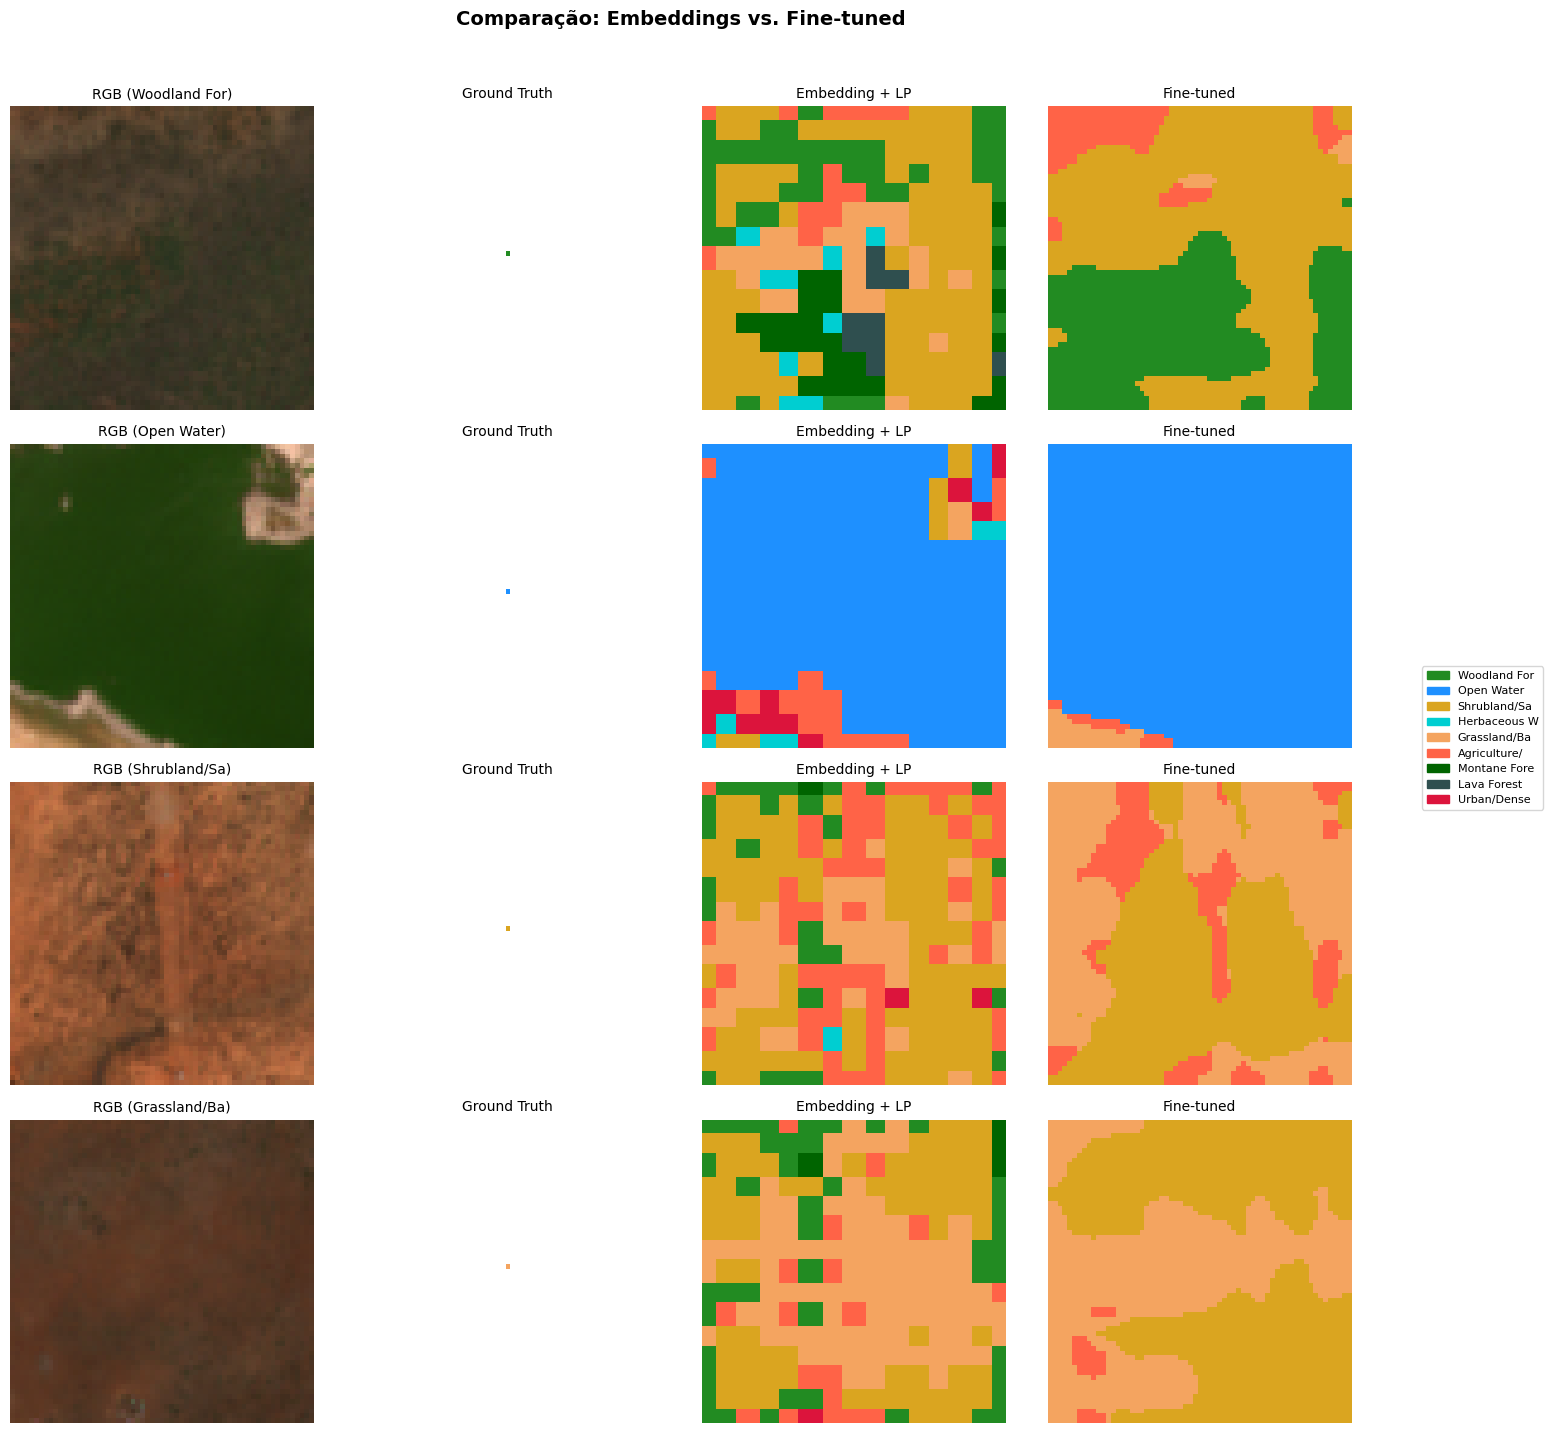

In [ ]:
# Carrega o encoder pré-treinado para comparar os embeddings (excluímos anteriormente para economizar memória)
print("Carregando o encoder pré-treinado para comparação de embeddings...")
encoder = load_model_from_id(ModelID.OLMOEARTH_V1_NANO).encoder.to(device)
encoder.eval()
print("  Encoder pré-treinado carregado")

# Carrega os pesos do modelo em que aplicamos o fine-tuning com base no checkpoint
# Encontra o melhor checkpoint
best_ckpt = "checkpoints/last.ckpt"
if os.path.exists("checkpoints"):
    ckpts = [f for f in os.listdir("checkpoints") if f.endswith(".ckpt") and f != "last.ckpt"]
    if ckpts:
        best_ckpt = f"checkpoints/{ckpts[0]}"

print(f"Carregando o modelo com fine-tuning do checkpoint: {best_ckpt}")
checkpoint = torch.load(best_ckpt, map_location=device, weights_only=False)
state_dict = checkpoint['state_dict']

# Carrega os pesos do encoder com fine-tuning
ft_encoder = load_model_from_id(ModelID.OLMOEARTH_V1_NANO).encoder.to(device)
encoder_state = {k.replace('model.encoder.0.model.', ''): v
                 for k, v in state_dict.items() if 'encoder.0.model.' in k}
ft_encoder.load_state_dict(encoder_state, strict=False)
ft_encoder.eval()

# Carrega os pesos do decoder head
ft_head = torch.nn.Sequential(
    torch.nn.Upsample(scale_factor=4, mode='bilinear', align_corners=False),
    torch.nn.Conv2d(128, 10, kernel_size=1)
).to(device)
for k, v in state_dict.items():
    if 'decoders.segment.1.layer.weight' in k:
        ft_head[1].weight.data = v
    if 'decoders.segment.1.layer.bias' in k:
        ft_head[1].bias.data = v

print(f"  Carregado {len(encoder_state)} encoder weights + decoder head")

def predict_finetuned(s2_data, output_shape):
    """Execute o modelo ajustado nos dados Sentinel-2 normalizados."""
    T, C, H, W = s2_data.shape
    s2_tensor = torch.from_numpy(s2_data.astype(np.float32)).to(device)
    s2_tensor = rearrange(s2_tensor, 't c h w -> 1 h w t c')

    mask = torch.full((1, H, W, T, 3), MaskValue.ONLINE_ENCODER.value, dtype=torch.int32, device=device)
    timestamps = torch.zeros((1, T, 3), dtype=torch.int32, device=device)
    timestamps[0, :, 1] = torch.arange(T, device=device)
    sample = MaskedOlmoEarthSample(sentinel2_l2a=s2_tensor, sentinel2_l2a_mask=mask, timestamps=timestamps)

    with torch.no_grad():
        output = ft_encoder(sample, fast_pass=True, patch_size=4)
        tokens = output['tokens_and_masks'].sentinel2_l2a.mean(dim=(3, 4))
        features = rearrange(tokens, 'b h w c -> b c h w')
        logits = ft_head(features)
        pred = logits.argmax(dim=1).cpu().numpy()[0]

    # Upsample para o tamanho do output
    scale_h, scale_w = output_shape[0] / pred.shape[0], output_shape[1] / pred.shape[1]
    return zoom(pred.astype(float), (scale_h, scale_w), order=0).astype(int)

# Compara as previsões lado a lado
fig, axes = plt.subplots(len(demo_windows), 4, figsize=(14, 3.5 * len(demo_windows)))
if len(demo_windows) == 1:
    axes = axes.reshape(1, -1)

for i, (window, true_label) in enumerate(demo_windows):
    # Use o último intervalo temporal (geralmente na estação seca) para uma visualização mais nítida
    rgb = load_rgb_image(window, DATASET_PATH, timestep=11)
    if rgb is None:  # Fallback para qualquer timestep disponível
        rgb = load_rgb_image(window, DATASET_PATH, timestep=0)
    s2_data, _ = load_window_data(window, DATASET_PATH)
    window_root = window.get_window_root(DATASET_PATH, window.group, window.name)
    with rasterio.open(str(window_root / "layers" / "label" / "category" / "geotiff.tif")) as src:
        label_map = src.read(1)

    # Predição de embeddings
    emb_pred = predict_segmentation(encoder, s2_data, lp, scaler, label_map.shape, device)

    # Predição com o modelo ajustado (fine-tuned)
    ft_pred = predict_finetuned(s2_data, label_map.shape)

    # Plot
    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title(f"RGB ({CLASS_NAMES[true_label][:12]})", fontsize=10)
    axes[i, 0].axis('off')

    masked = np.ma.masked_where(label_map >= len(CLASS_NAMES), label_map)
    axes[i, 1].imshow(masked, cmap=cmap, vmin=0, vmax=len(CLASS_NAMES)-1)
    axes[i, 1].set_title("Ground Truth", fontsize=10)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(emb_pred, cmap=cmap, vmin=0, vmax=len(CLASS_NAMES)-1)
    axes[i, 2].set_title("Embedding + LP", fontsize=10)
    axes[i, 2].axis('off')

    axes[i, 3].imshow(ft_pred, cmap=cmap, vmin=0, vmax=len(CLASS_NAMES)-1)
    axes[i, 3].set_title("Fine-tuned", fontsize=10)
    axes[i, 3].axis('off')

fig.legend(handles=patches, loc='center right', bbox_to_anchor=(1.12, 0.5), fontsize=8)
plt.suptitle("Comparação: Embeddings vs. Fine-tuned", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Resumo

In [ ]:
print("="*60)
print("RESUMO FINAL")
print("="*60)
print(f"\nBaseado em embeddings (sem fine-tuning):")
print(f"  Acurácia com kNN:          {knn_accuracy:.1%}")
print(f"  Acurácia com Linear Probe: {lp_accuracy:.1%}")
print(f"\nFine-tuning aplicado no OlmoEarth Nano ({NUM_EPOCHS} épocas):")
if finetune_accuracy is not None:
    print(f"  Acurácia de validação:   {finetune_accuracy:.1%}")
else:
    print(f"  Acurácia de validação:   (ver os logs de treinamento acima)")
print(f"\nReferência (do paper do OlmoEarth, usando 30 épocas de fine-tuning):")
print(f"  OlmoEarth Nano (S2):   82.5%  (aumente o número de épocas para obter resultados semelhantes)")
print(f"  OlmoEarth Base (S2):   87.0%  (mude o modelo <model_id> para OLMOEARTH_V1_BASE)")
print("="*60)

# Mostrar melhorias decorrentes do fine-tuning
if finetune_accuracy is not None:
    best_embedding = max(knn_accuracy, lp_accuracy)
    improvement = finetune_accuracy - best_embedding
    print(f"\nMelhorias com o fine-tuning: +{improvement:.1%} em relação ao melhor resultado do embedding-based")

RESUMO FINAL

Baseado em embeddings (sem fine-tuning):
  Acurácia com kNN:          71.5%
  Acurácia com Linear Probe: 68.3%

Fine-tuning aplicado no OlmoEarth Nano (30 épocas):
  Acurácia de validação:   80.6%

Referência (do paper do OlmoEarth, usando 30 épocas de fine-tuning):
  OlmoEarth Nano (S2):   82.5%  (aumente o número de épocas para obter resultados semelhantes)
  OlmoEarth Base (S2):   87.0%  (mude o modelo <model_id> para OLMOEARTH_V1_BASE)

Melhorias com o fine-tuning: +9.1% em relação ao melhor resultado do embedding-based


### Quando usar cada abordagem?

| Cenário | Abordagem recomendada |
|----------|---------------------|
| Prototipagem rápida e exploração de dados | Embeddings + kNN/LP |
| GPU limitada | Embeddings + kNN/LP |
| Dataset com poucas amostras rotuladas (<100 samples) | Embeddings + kNN/LP |
| Máxima acurácia requerida | Fine-tuning |
| Implantação em produção | Fine-tuning |
| Aplicação final muito diferente do pré-treinamento | Fine-tuning |

**Dica**: Comece com os *embeddings* para uma exploração rápida/ validar rapidamente sua abordagem, depois parta para o *fine-tuning*!

---
## 7. Próximos passos & Recursos

### Ampliação

| Modelo | Parâmetros | Embedding Dim | Acurácia esperada |
|-------|------------|---------------|-------------------|
| **Nano** (desse tutorial) | 1.4M | 128 | ~82% |
| Tiny | 6.2M | 192 | ~85% |
| Base | 90M | 768 | ~87% |
| Large | 300M | 1024 | ~85%* |

Para usar um modelo maior, troque `model_id: OLMOEARTH_V1_NANO` para `OLMOEARTH_V1_BASE` e atualize `in_channels` adequadamente.

### Recursos

- **OlmoEarth Models**: [huggingface.co/allenai](https://huggingface.co/collections/allenai/olmoearth)
- **rslearn Library**: [github.com/allenai/rslearn](https://github.com/allenai/rslearn)
- **OlmoEarth Projects**: [github.com/allenai/olmoearth_projects](https://github.com/allenai/olmoearth_projects)

### Citação

Se você utilizar o OlmoEarth em seu trabalho, por favor, cite:

```bibtex
@misc{herzog2025olmoearth,
  title={OlmoEarth: Stable Latent Image Modeling for Multimodal Earth Observation},
  author={Henry Herzog and Favyen Bastani and Yawen Zhang and Gabriel Tseng and Joseph Redmon and others},
  year={2025},
  eprint={2511.13655},
  archivePrefix={arXiv}
}
```

---

**Parabéns!**

Você aprendeu como:

1. Carregar e explorar *datasets* de sensoriamento remoto com ``rslearn``;
2. Extrair *embeddings* com o FM OlmoEarth para rápida prototipagem;
3. Treinar classificadores simples (kNN e Linear Probe) com base nos *embeddings*.
4. Aplicar fine-tuning e adaptar o modelo para a sua aplicação

<small>O tutorial original em inglês está disponível em: https://docs.olmoearth.allenai.org/embeddings/.</small>

**Bio**

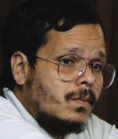

Alisson de Oliveira é Bacharel em Gestão e Análise Ambiental pela Universidade Federal de São Carlos (UFSCar) desde 2021 e Mestre em Sensoriamento Remoto pelo Instituto Nacional de Pesquisas Espaciais (INPE) desde 2024. Atualmente está no terceiro ano do doutorando em Sensoriamento Remoto no INPE, onde desenvolve pesquisas voltadas à análise ambiental utilizando dados de sensoriamento remoto e *machine learning*, como foco na utilização dos satélites brasileiros CBERS-4, CBERS-4A e AMAZONIA-1